# Operations, Monitoring & Evidence
Covers **Stage 4.** Complete every `# TODO` in this notebook **and** in the `src/` modules it imports. 
- Each stage opens with a **sub-task checklist**
- Capture any repo-generated evidence (MLflow UI, Docker build, CI run, drift report) as screenshots/summaries **inside the notebook/report**.

**File ownership** — 
- *Provided:* `config.py`, `src/evaluate.py`. 
- *Provided to extend:* `src/monitoring.py`, `src/retrain.py`, `src/model.py` (EmbeddingExtractor). 
- *You build:* this notebook.

### 0. Setup

In [29]:
import config, json
# TODO: load artifacts/drift_summary.json after running src.monitoring
import json

import config

# Set the drift summary path by joining the artifact directory with the filename "drift_summary.json".
drift_summary_path = (
    config.ARTIFACT_DIR
    / "drift_summary.json"
)

# If the drift summary file exists, read its contents and load it as a JSON object. 
# Otherwise, set drift_summary to None and print a message indicating that the drift summary is not available yet.
if drift_summary_path.exists():
    drift_summary = json.loads(
        drift_summary_path.read_text(
            encoding="utf-8"
        )
    )

    print(
        "Loaded drift summary:",
        drift_summary_path,
    )
else:
    drift_summary = None

    print(
        "Drift summary not available yet."
    )
    print(
        "Run `python -m src.monitoring` "
        "after completing the monitoring implementation."
    )

Loaded drift summary: C:\Users\naren\Documents\MLOps-Capstone\capstone\artifacts\drift_summary.json


In [30]:
# Assert that the drift summary is not None to ensure that the drift summary has been successfully loaded 
# before proceeding with further analysis or printing its contents.
assert drift_summary is not None

print(
    "Retraining recommended:",
    drift_summary["retrain_recommended"],
)

print(
    "Trigger reasons:",
    drift_summary["trigger_reasons"],
)

Retraining recommended: True
Trigger reasons: ['feature_drift', 'embedding_drift']


In [31]:
# Generate a small set of served predictions for monitoring evidence.

import mimetypes

from fastapi.testclient import TestClient

from app import app
from src import data_prep


# Load the versioned test split.
data_root = data_prep.find_data_root()

# Load the test split of the dataset using the data_prep module, specifying the version and name of the split, 
# and providing the root directory where the data is located.
test_items = data_prep.load_split(
    version="v1",
    name="test",
    root=data_root,
)

# Select 3 examples from each class.
ok_examples = [
    (path, label)
    for path, label in test_items
    if label == config.CLASS_TO_IDX["ok_front"]
][:3]

defect_examples = [
    (path, label)
    for path, label in test_items
    if label == config.CLASS_TO_IDX["def_front"]
][:3]

examples_to_serve = (
    ok_examples
    + defect_examples
)

print(
    "Images selected:",
    len(examples_to_serve),
)


# Calling the real FastAPI endpoint also exercises
# the production prediction-logging path.

# Pass the FastAPI app instance to the TestClient, which allows for testing the API endpoints without running a live server.
with TestClient(app) as client:

    # Check the health of the FastAPI application by sending a GET request to the "/health" endpoint 
    # and asserting that the response status code is 200 and that the model is loaded successfully.
    health_response = client.get(
        "/health"
    )

    assert health_response.status_code == 200
    assert health_response.json()[
        "model_loaded"
    ] is True

    prediction_results = []

    # Iterate over the selected examples to serve, sending each image to the "/predict" endpoint of the FastAPI application
    for image_path, true_label in examples_to_serve:

        content_type = (
            mimetypes.guess_type(
                image_path.name
            )[0]
            or "application/octet-stream"
        )

        # Open the image file in binary mode and send a POST request to the "/predict" endpoint with the image file as part of the request.
        with image_path.open("rb") as image_file:

            response = client.post(
                "/predict",
                files={
                    "file": (
                        image_path.name,
                        image_file,
                        content_type,
                    )
                },
            )

        # Assert that the response status code is 200 to ensure that the prediction request was successful.
        assert response.status_code == 200, (
            response.text
        )

        result = response.json()

        # Append the prediction results, including the filename, true label, predicted label, confidence score, 
        # and probability of defect, to the prediction_results list for further analysis and display.
        prediction_results.append(
            {
                "filename": image_path.name,
                "true_label": (
                    config.IDX_TO_CLASS[
                        true_label
                    ]
                ),
                "predicted_label": (
                    result["label"]
                ),
                "confidence": (
                    result["confidence"]
                ),
                "prob_defect": (
                    result["prob_defect"]
                ),
            }
        )


prediction_results_df = pd.DataFrame(
    prediction_results
)

display(
    prediction_results_df
)

print(
    "PASS:",
    len(prediction_results),
    "images served through /predict.",
)

Images selected: 6


,filename,true_label,predicted_label,confidence,prob_defect
0,cast_ok_0_10.jpeg,ok_front,def_front,0.548952,0.548952
1,cast_ok_0_1132.jpeg,ok_front,ok_front,0.539527,0.460473
2,cast_ok_0_1134.jpeg,ok_front,def_front,0.559399,0.559399
3,cast_def_0_1059.jpeg,def_front,def_front,0.506523,0.506523
4,cast_def_0_1063.jpeg,def_front,def_front,0.637262,0.637262
5,cast_def_0_108.jpeg,def_front,def_front,0.509166,0.509166


PASS: 6 images served through /predict.


## **Stage 4.1 — Prediction Logging & Confidence Monitoring** <font color="red">[5 marks]</font>

- **4.1.1 — Prediction logging with timestamp [2]** — *to be done in this notebook and the report*
- **4.1.2 — Confidence monitoring reference vs current + threshold [3]** — *to be done in this notebook and the report*

**Objective:** Log predictions and watch mean confidence drift.

**Implement in:** app.py (logging) + src/monitoring.py (confidence)

**Inputs → Outputs:** served predictions → predictions.log; reference vs current → confidence drop + alert

**TODO:** log each prediction with a timestamp (4.1.1); compute mean predicted-confidence on reference vs a current batch with an alert threshold (4.1.2).

**Depends on:** Stage 3.4 completed in Model_Development_and_Tracking.ipynb ·  **Document here:** the confidence reference→current + log tail.

In [32]:
# TODO 4.1.1-4.1.2: show predictions.log tail + confidence block from drift_summary.json
# Stage 4.1.1 — Prediction logging with timestamp

from collections import deque

import pandas as pd
from IPython.display import display

import config
import json

prediction_log_path = config.PREDICTIONS_LOG

# Assert that the prediction log file exists to ensure that predictions have been logged before attempting to read and display them.
assert prediction_log_path.exists(), (
    f"Prediction log not found: {prediction_log_path}"
)

# Read only the most recent predictions rather than loading
# an indefinitely growing production log.

# Use a deque to efficiently retrieve the last 5 non-empty lines from the prediction log file, stripping any leading 
# or trailing whitespace from each line.
with prediction_log_path.open(
    "r",
    encoding="utf-8",
) as log_file:
    recent_lines = list(
        deque(
            (
                line.strip()
                for line in log_file
                if line.strip()
            ),
            maxlen=5,
        )
    )

# Convert the recent lines from the prediction log into a list of JSON objects by loading each line as a JSON record.
recent_predictions = [
    json.loads(line)
    for line in recent_lines
]

# Assert that there are recent predictions to display, ensuring that the prediction log contains 
# records before attempting to process and display them.
assert recent_predictions, (
    "Prediction log exists but contains no records."
)

# Confirm that every displayed prediction contains a timestamp.
assert all(
    "timestamp_utc" in record
    for record in recent_predictions
)

# Define the columns to be displayed from the prediction log, including timestamp, filename, label, defect status, 
# probability of defect, confidence score, and latency in milliseconds.
prediction_columns = [
    "timestamp_utc",
    "filename",
    "label",
    "is_defective",
    "prob_defect",
    "confidence",
    "latency_ms",
]

# Create a DataFrame from the recent predictions to facilitate structured display and analysis of the prediction records.
prediction_log_tail = pd.DataFrame(
    recent_predictions
)

# Display the relevant columns from the prediction log tail, filtering to include only those columns that are present in the DataFrame.
display(
    prediction_log_tail[
        [
            column
            for column in prediction_columns
            if column in prediction_log_tail.columns
        ]
    ]
)

print(
    f"PASS: displaying the latest "
    f"{len(recent_predictions)} prediction record(s)."
)

print(
    "Prediction log:",
    prediction_log_path,
)

,timestamp_utc,filename,label,is_defective,prob_defect,confidence,latency_ms
0,2026-08-15T10:07:11.423159+00:00,cast_ok_0_1132.jpeg,ok_front,False,0.460473,0.539527,41.022
1,2026-08-15T10:07:11.466224+00:00,cast_ok_0_1134.jpeg,def_front,True,0.559399,0.559399,37.279
2,2026-08-15T10:07:11.506138+00:00,cast_def_0_1059.jpeg,def_front,True,0.506523,0.506523,38.754
3,2026-08-15T10:07:11.551648+00:00,cast_def_0_1063.jpeg,def_front,True,0.637262,0.637262,36.253
4,2026-08-15T10:07:11.593182+00:00,cast_def_0_108.jpeg,def_front,True,0.509166,0.509166,37.891


PASS: displaying the latest 5 prediction record(s).
Prediction log: C:\Users\naren\Documents\MLOps-Capstone\capstone\artifacts\predictions.log


In [33]:
# Stage 4.1.2 — Reference vs current confidence monitoring

# Assert that the drift summary is not None to ensure that the drift summary has been successfully loaded 
# before proceeding with further analysis or printing its contents.
assert drift_summary is not None, (
    "Run src.monitoring before displaying confidence results."
)

# Extract the confidence metrics from the drift summary for further analysis and display.
confidence = drift_summary["confidence"]

# Extract individual confidence metrics from the confidence dictionary for easier access and display.
reference_mean = confidence["reference_mean"]
current_mean = confidence["current_mean"]
confidence_drop = confidence["drop"]
threshold = confidence["threshold"]
alert = confidence["alert"]

# Create a DataFrame to summarize the confidence metrics, including reference mean confidence, current mean confidence,
# confidence drop, and the alert threshold, for structured display and analysis.
confidence_results = pd.DataFrame(
    {
        "Metric": [
            "Reference mean confidence",
            "Current mean confidence",
            "Confidence drop",
            "Alert threshold",
        ],
        "Value": [
            reference_mean,
            current_mean,
            confidence_drop,
            threshold,
        ],
    }
)

# Display the confidence results DataFrame with formatted values for better readability, 
# showing the metrics and their corresponding values.
display(
    confidence_results.style.format(
        {
            "Value": "{:.4f}",
        }
    )
)

print(
    "Confidence alert:",
    alert,
)

if alert:
    print(
        "ALERT: mean confidence has dropped "
        "beyond the configured threshold."
    )
else:
    print(
        "PASS: confidence drop does not exceed "
        "the configured threshold."
    )

,Metric,Value
0,Reference mean confidence,0.5713
1,Current mean confidence,0.6157
2,Confidence drop,-0.0444
3,Alert threshold,0.1000


Confidence alert: False
PASS: confidence drop does not exceed the configured threshold.


### Stage 4.1 interpretation

Each successful API prediction is recorded in `predictions.log` as a JSON Lines
record containing a UTC timestamp together with the prediction result,
confidence and inference latency. This provides a simple auditable record of
served predictions for downstream monitoring.

The clean reference batch had a mean prediction confidence of approximately
**0.5713**, while the simulated current batch had a mean confidence of
approximately **0.6157**. The resulting confidence drop was **-0.0444**, which
does not exceed the configured alert threshold of **0.10**.

The negative confidence drop means that average model confidence increased
rather than decreased under the simulated drift. Therefore, confidence
monitoring did not raise an alert. This demonstrates why confidence alone is
not a sufficient monitoring signal: the model may remain confident, or even
become more confident, despite a substantial change in the input distribution.

## **Stage 4.2 — Statistical Drift Detection (Evidently + PSI)** <font color="red">[8 marks]</font>

- **4.2.1 — Per-image features + Evidently DataDriftPreset [4]** — *to be done in this notebook and the report*
- **4.2.2 — PSI per feature + interpretation [4]**— *to be done in this notebook and the report*

**Objective:** Detect drift in interpretable image features.

**Implement in:** src/monitoring.py

**Inputs → Outputs:** reference vs simulated current batch → per-feature drift + PSI + HTML report

**TODO:** compute image features + run Evidently DataDriftPreset reference vs a simulated current batch (4.2.1); compute PSI per feature + interpret + save drift_report.html (4.2.2).

**Document here:** the per-feature PSI table/plot + dataset_drift flag.

In [34]:
# TODO 4.2.1-4.2.2: !python -m src.monitoring ; bar-plot feature PSI vs the 0.2 threshold
# Stage 4.2.1 — Statistical drift detection using interpretable image features

import pandas as pd
from IPython.display import display, FileLink

# Assert that the drift summary is not None to ensure that the drift summary has been successfully loaded 
# before proceeding with further analysis and display of drift results.
assert drift_summary is not None, (
    "Run `python -m src.monitoring` before displaying drift results."
)

# Extract the feature drift information from the drift summary for further analysis and display.
feature_drift = drift_summary["feature_drift"]

# Extract individual feature drift metrics from the feature_drift dictionary for easier access and display.
feature_psi = feature_drift["psi"]
psi_threshold = feature_drift["threshold"]
drifted_features = feature_drift["drifted_features"]
drift_share = feature_drift["drift_share"]
dataset_drift = feature_drift["dataset_drift"]

# Define the path to the drift report by joining the artifact directory with the filename "drift_report.html".
drift_report_path = (
    config.ARTIFACT_DIR
    / "drift_report.html"
)

# Check if the drift report file exists and assert its existence to ensure that the drift report has been 
# generated before attempting to display it.
assert drift_report_path.exists(), (
    f"Evidently drift report not found: {drift_report_path}"
)

# Print the monitored image features, drifted features, drifted feature share, and whether dataset drift was detected,
# providing a summary of the drift analysis results.
print(
    "Monitored image features:",
    list(feature_psi.keys()),
)

print(
    "Drifted features:",
    drifted_features,
)

print(
    f"Drifted feature share: {drift_share:.2%}"
)

print(
    "Dataset drift detected:",
    dataset_drift,
)

print(
    "\nEvidently report:"
)

display(
    FileLink(
        str(drift_report_path)
    )
)

Monitored image features: ['brightness', 'contrast', 'edge_density', 'sharpness', 'mean_intensity']
Drifted features: ['brightness', 'contrast', 'edge_density', 'sharpness', 'mean_intensity']
Drifted feature share: 100.00%
Dataset drift detected: True

Evidently report:


C:\Users\naren\Documents\MLOps-Capstone\capstone\artifacts\drift_report.html

In [35]:
# Stage 4.2.2 — Per-feature Population Stability Index

# Create a DataFrame to summarize the Population Stability Index (PSI) for each feature, including the PSI value,
# the threshold for drift detection, and whether the feature is considered drifted based on the PSI value exceeding the threshold.
psi_table = pd.DataFrame(
    {
        "Feature": list(
            feature_psi.keys()
        ),
        "PSI": list(
            feature_psi.values()
        ),
    }
)

psi_table["Threshold"] = (
    psi_threshold
)

psi_table["Drifted"] = (
    psi_table["PSI"]
    > psi_table["Threshold"]
)

# Display the PSI table with formatted values for better readability, showing the feature names, PSI values, thresholds, and drift status.
display(
    psi_table.style.format(
        {
            "PSI": "{:.4f}",
            "Threshold": "{:.2f}",
        }
    )
)

# Assert that the number of drifted features in the PSI table matches the length of the drifted_features list 
# to ensure consistency between the two representations of drifted features.
assert (
    psi_table["Drifted"].sum()
    == len(drifted_features)
)

print(
    f"{psi_table['Drifted'].sum()} of "
    f"{len(psi_table)} features exceeded "
    f"the PSI threshold of {psi_threshold:.2f}."
)

,Feature,PSI,Threshold,Drifted
0,brightness,11.0507,0.20,True
1,contrast,11.0507,0.20,True
2,edge_density,11.0507,0.20,True
3,sharpness,11.0507,0.20,True
4,mean_intensity,11.0507,0.20,True


5 of 5 features exceeded the PSI threshold of 0.20.


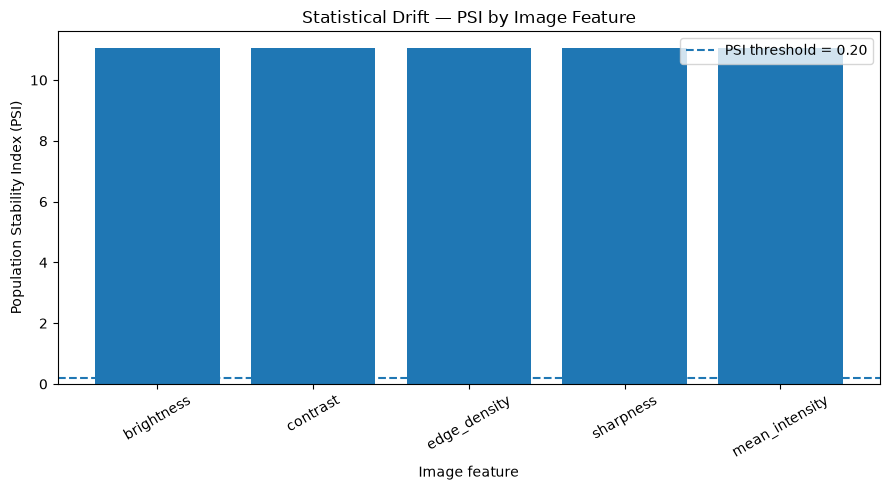

In [36]:
# Visualise per-feature PSI against the configured threshold.

import matplotlib.pyplot as plt


fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.bar(
    psi_table["Feature"],
    psi_table["PSI"],
)

ax.axhline(
    y=psi_threshold,
    linestyle="--",
    label=f"PSI threshold = {psi_threshold:.2f}",
)

ax.set_title(
    "Statistical Drift — PSI by Image Feature"
)

ax.set_xlabel(
    "Image feature"
)

ax.set_ylabel(
    "Population Stability Index (PSI)"
)

ax.tick_params(
    axis="x",
    rotation=30,
)

ax.legend()

plt.tight_layout()
plt.show()

In [37]:
drift_share_threshold = feature_drift[
    "drift_share_threshold"
]

print(
    f"Drifted feature share : {drift_share:.2%}"
)

print(
    f"Trigger threshold      : {drift_share_threshold:.2%}"
)

print(
    f"Dataset drift          : {dataset_drift}"
)

Drifted feature share : 100.00%
Trigger threshold      : 40.00%
Dataset drift          : True


### Stage 4.2 interpretation

Statistical drift was evaluated using five interpretable image characteristics:
**brightness, contrast, edge density, sharpness and mean intensity**. The clean
versioned test batch was used as the reference distribution and a simulated
production batch containing camera- and lighting-like corruption was used as
the current distribution.

Evidently `DataDriftPreset` was used to generate an HTML drift report, while
Population Stability Index (PSI) was calculated independently for each image
feature using reference-derived quantile bins.

All five monitored image features produced a PSI of approximately **11.0507**,
well above the configured feature-drift threshold of **0.20**. Therefore
**5/5 features (100%)** were classified as drifted. This exceeds the configured
dataset-level drift-share threshold of **40%**, so dataset drift was detected.

The identical PSI values across all five features occur because the simulated
corruption caused each current feature distribution to become almost completely
separated from its corresponding clean reference distribution. The PSI
implementation uses quantile bins derived from the reference data together with
the same small epsilon value to avoid zero proportions. When the current values
are concentrated in different bins from the reference values, the histogram
proportions for several features can become effectively identical after this
smoothing step. As a result, strongly separated distributions can produce the
same PSI value even though the underlying image features are different.

The very large PSI values therefore indicate **extreme distribution separation**
rather than a meaningful linear measure of drift severity. Once PSI is far above
the configured threshold, the important operational conclusion is that
significant drift is present, rather than whether one feature has a PSI of 8,
10 or 12.

The result confirms that the simulated lighting, blur, rotation and sensor
noise substantially changed the observable characteristics of the production
images.

## **Stage 4.3 — Embedding Drift Detection** <font color="red">[7 marks]</font>

- **4.3.1 — 512-dim embedding extraction (reference + current) [3]** — *to be done in this notebook*
- **4.3.2 — Feature-space drift quantified (PSI) + explanation [4]** — *to be done in this notebook and the report*

### How embedding drift works (conceptual scaffolding — implement these 4 steps)
Raw-pixel features can miss *semantic* drift, so also measure drift in the model's **feature space**:
1. **Feature extraction** — use the model's **penultimate layer** (the 512-dim vector before the final classifier) as an image **embedding** (`EmbeddingExtractor` in `src/model.py`). *(4.3.1)*
2. **Embedding generation** — run the reference set and the current batch through the backbone and collect the embedding vectors (save reference to `reference_embeddings.npz`). *(4.3.1)*
3. **Feature-space comparison** — reduce each embedding to a scalar **distance to the reference centroid** (mean reference embedding) → one distribution per batch. *(4.3.2)*
4. **Drift calculation** — compute **PSI** between the reference and current distance distributions; PSI above ~0.10 signals embedding drift even when raw pixels look similar. *(4.3.2)*

**TODO:** implement steps 1–4 in `src/model.EmbeddingExtractor` + `src/monitoring.py`; report the embedding PSI and whether it exceeds the threshold.

**Document here:** the embedding PSI + a one-line interpretation of why embedding drift differs from feature drift.

In [41]:
# TODO 4.3.1-4.3.2: extract embeddings (reference + current); PSI on distance-to-centroid; print PSI vs 0.10
# Stage 4.3.1 — 512-dimensional embedding extraction
# using the fixed production reference baseline.

import numpy as np
import torch
from PIL import Image

from src import data_prep
from src.model import (
    load_model,
    EmbeddingExtractor,
)
from src.monitoring import corrupt, psi


np.random.seed(
    config.RANDOM_SEED
)

# Load the deployed production model.
production_model = load_model(
    path=config.MODEL_PATH,
    freeze=True,
)

production_model.eval()

embedding_extractor = EmbeddingExtractor(
    production_model
).to(
    config.DEVICE
)

embedding_extractor.eval()

eval_transform = data_prep.get_transforms(
    train=False
)

data_root = data_prep.find_data_root()

# The production monitoring baseline was created
# from the clean validation split.
reference_items = data_prep.load_split(
    version="v1",
    name="val",
    root=data_root,
)

reference_images = []
current_images = []

for image_path, _ in reference_items:

    with Image.open(image_path) as opened_image:
        clean_image = (
            opened_image
            .convert("L")
            .copy()
        )

    reference_images.append(
        clean_image
    )

    current_images.append(
        corrupt(clean_image)
    )


def extract_embeddings(
    images,
    batch_size=config.BATCH_SIZE,
):

    embedding_batches = []

    for start in range(
        0,
        len(images),
        batch_size,
    ):

        batch_images = images[
            start:start + batch_size
        ]

        tensor_batch = torch.stack(
            [
                eval_transform(image)
                for image in batch_images
            ]
        ).to(
            config.DEVICE
        )

        with torch.no_grad():

            batch_embeddings = (
                embedding_extractor(
                    tensor_batch
                )
            )

        embedding_batches.append(
            batch_embeddings
            .cpu()
            .numpy()
        )

    return np.concatenate(
        embedding_batches,
        axis=0,
    )


# Regenerate the reference embeddings to demonstrate
# 512-D feature extraction in the notebook.
generated_reference_embeddings = (
    extract_embeddings(
        reference_images
    )
)

# Extract current simulated-production embeddings.
current_embeddings = extract_embeddings(
    current_images
)

# Load the fixed baseline created during training.
with np.load(
    config.REFERENCE_EMBED
) as baseline:

    reference_embeddings = (
        baseline["embeddings"]
    )

    reference_centroid = (
        baseline["centroid"]
    )


print(
    "Stored reference embeddings:",
    reference_embeddings.shape,
)

print(
    "Generated reference embeddings:",
    generated_reference_embeddings.shape,
)

print(
    "Current embeddings:",
    current_embeddings.shape,
)

print(
    "Reference centroid:",
    reference_centroid.shape,
)


assert reference_embeddings.shape == (
    len(reference_items),
    config.EMBEDDING_DIM,
)

assert current_embeddings.shape == (
    len(reference_items),
    config.EMBEDDING_DIM,
)

assert reference_centroid.shape == (
    config.EMBEDDING_DIM,
)

# Confirm that the fixed stored baseline belongs to
# the production model currently being monitored.
assert np.allclose(
    generated_reference_embeddings,
    reference_embeddings,
    rtol=1e-4,
    atol=1e-5,
)

print(
    "PASS: fixed reference baseline matches "
    "the production model."
)

print(
    f"PASS: reference and current images have "
    f"{config.EMBEDDING_DIM}-D embeddings."
)

Stored reference embeddings: (12, 512)
Generated reference embeddings: (12, 512)
Current embeddings: (12, 512)
Reference centroid: (512,)
PASS: fixed reference baseline matches the production model.
PASS: reference and current images have 512-D embeddings.


In [46]:
# Stage 4.3.2 — Quantify feature-space drift.

print(
    "Reference centroid shape:",
    reference_centroid.shape,
)

# Assert that the shape of the reference centroid matches the expected embedding dimension defined in the configuration.
assert reference_centroid.shape == (
    config.EMBEDDING_DIM,
)

# Reduce every 512-D embedding to one scalar:
# Euclidean distance from the clean reference centroid for the reference embeddings.
reference_distances = np.linalg.norm(
    reference_embeddings
    - reference_centroid,
    axis=1,
)

# Reduce every 512-D embedding to one scalar:
# Euclidean distance from the clean reference centroid for the current embeddings.
current_distances = np.linalg.norm(
    current_embeddings
    - reference_centroid,
    axis=1,
)

print(
    "Reference distance samples:",
    reference_distances.shape[0],
)

print(
    "Current distance samples:",
    current_distances.shape[0],
)

# Compare the two distance distributions using PSI.
embedding_psi = psi(
    reference_distances,
    current_distances,
)

embedding_threshold = (
    config.EMBEDDING_DRIFT_THRESHOLD
)

# Check if the embedding PSI exceeds the configured threshold to determine if embedding drift has been detected.
embedding_drift_detected = (
    embedding_psi
    > embedding_threshold
)

print(
    f"\nEmbedding PSI      : "
    f"{embedding_psi:.4f}"
)

print(
    f"Drift threshold    : "
    f"{embedding_threshold:.2f}"
)

print(
    "Embedding drift    :",
    embedding_drift_detected,
)

Reference centroid shape: (512,)
Reference distance samples: 12
Current distance samples: 12

Embedding PSI      : 11.0507
Drift threshold    : 0.10
Embedding drift    : True


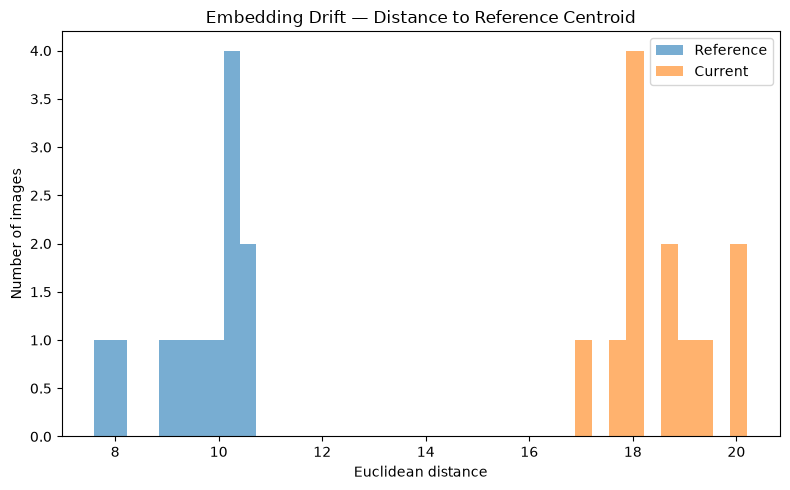

In [44]:
# Visualise the distance distributions for the reference and current embeddings.
import matplotlib.pyplot as plt


fig, ax = plt.subplots(
    figsize=(8, 5)
)

# Plot histograms of the reference and current distance distributions, using 10 bins for each histogram,
# with an alpha transparency of 0.6, and labeling them as "Reference" and "Current" respectively for the legend.
ax.hist(
    reference_distances,
    bins=10,
    alpha=0.6,
    label="Reference",
)

ax.hist(
    current_distances,
    bins=10,
    alpha=0.6,
    label="Current",
)

ax.set_title(
    "Embedding Drift — Distance to Reference Centroid"
)

ax.set_xlabel(
    "Euclidean distance"
)

ax.set_ylabel(
    "Number of images"
)

ax.legend()

plt.tight_layout()
plt.show()

### Embedding distance distribution

The reference and current embedding-distance distributions show almost complete
separation. Clean reference images lie substantially closer to the reference
centroid, while the simulated current images have much larger Euclidean
distances.

This indicates that the simulated production corruption does not only alter
simple image characteristics; it also moves the images into a different region
of the feature space learned by ResNet18. The strong separation explains the
high embedding PSI of approximately **11.0507**, which is well above the
configured embedding-drift threshold of **0.10**.

The embedding-drift result therefore provides model-aware evidence that the
current production-like images differ materially from the clean reference
baseline.

### Stage 4.3 interpretation

The production ResNet18 model was reused as a feature extractor by removing its
final classification layer. Each image was represented by the model's
**512-dimensional penultimate-layer embedding**.

The fixed clean production-monitoring baseline, created from the validation
split when the production model was prepared, contained **12 embeddings with
shape (12, 512)**. The simulated current batch also produced **12 embeddings
with shape (12, 512)**. The stored reference embeddings were verified against
embeddings regenerated from the currently loaded production model.

The embedding PSI was approximately **11.0507**, substantially above the
configured embedding-drift threshold of **0.10**. Embedding drift was therefore
detected.

#### Relationship between statistical and embedding drift

Stage 4.2 measures drift using **human-interpretable image properties** such as
brightness, contrast, edge density, sharpness and mean intensity. These
measurements determine whether the observable input distribution has changed.

Stage 4.3 instead measures drift in the model's **learned 512-dimensional
feature space**. It therefore determines whether the incoming images have
changed in a way that is also reflected in the internal representation used by
the classifier.

The two signals are complementary. Statistical drift can identify changes in
raw image characteristics even when the model representation remains stable,
while embedding drift can identify changes in learned visual patterns that may
not be apparent from simple image statistics.

In this experiment, both statistical feature drift and embedding drift were
detected, while mean prediction confidence did not decrease. This demonstrates
why operational monitoring benefits from combining multiple independent
signals rather than relying on prediction confidence alone.

## **Stage 4.4 — Retraining Workflow & Triggers** <font color="red">[6 marks]</font>

- **4.4.1 — Measurable retraining triggers [2]** — *to be done in this notebook and the report*
- **4.4.2 — Drift-triggered retraining + new version registered [4]** — *to be done in this notebook and the report*

**Objective:** Retrain a candidate when drift fires.

**Implement in:** src/retrain.py

**Inputs → Outputs:** drift signals → drift-augmented candidate model + new registry version

**TODO:** define multi-signal triggers (drift share / embedding PSI / confidence drop) (4.4.1); on a trigger, train a drift-augmented candidate + register a new version (4.4.2).

**Document here:** the trigger decision + candidate training summary.

In [45]:
# Stage 4.4.1 — Measurable retraining triggers

assert drift_summary is not None

feature_drift = (
    drift_summary["feature_drift"]
)

embedding_drift = (
    drift_summary["embedding_drift"]
)

confidence = (
    drift_summary["confidence"]
)


trigger_evidence = pd.DataFrame(
    [
        {
            "Signal":
                "Statistical feature PSI",
            "Threshold":
                config.PSI_THRESHOLD,
            "Observed":
                max(
                    feature_drift[
                        "psi"
                    ].values()
                ),
            "Triggered":
                bool(
                    feature_drift[
                        "drifted_features"
                    ]
                ),
        },
        {
            "Signal":
                "Drifted feature share",
            "Threshold":
                config.DRIFT_SHARE_THRESHOLD,
            "Observed":
                feature_drift[
                    "drift_share"
                ],
            "Triggered":
                feature_drift[
                    "dataset_drift"
                ],
        },
        {
            "Signal":
                "Embedding PSI",
            "Threshold":
                config.EMBEDDING_DRIFT_THRESHOLD,
            "Observed":
                embedding_drift[
                    "psi"
                ],
            "Triggered":
                embedding_drift[
                    "drifted"
                ],
        },
        {
            "Signal":
                "Confidence drop",
            "Threshold":
                config.CONFIDENCE_DROP_THRESHOLD,
            "Observed":
                confidence[
                    "drop"
                ],
            "Triggered":
                confidence[
                    "alert"
                ],
        },
    ]
)

display(
    trigger_evidence.style.format(
        {
            "Threshold": "{:.4f}",
            "Observed": "{:.4f}",
        }
    )
)

print(
    "Retraining recommended:",
    drift_summary[
        "retrain_recommended"
    ],
)

print(
    "Trigger reasons:",
    drift_summary[
        "trigger_reasons"
    ],
)

,Signal,Threshold,Observed,Triggered
0,Statistical feature PSI,0.2000,11.0507,True
1,Drifted feature share,0.4000,1.0000,True
2,Embedding PSI,0.1000,11.0507,True
3,Confidence drop,0.1000,-0.0444,False


Retraining recommended: True
Trigger reasons: ['feature_drift', 'embedding_drift']


In [47]:
# TODO 4.4.1-4.4.2: !python -m src.retrain ; load artifacts/retraining_decision.json
# Stage 4.4 — Retraining triggers and candidate training

retraining_decision_path = (
    config.ARTIFACT_DIR
    / "retraining_decision.json"
)

assert retraining_decision_path.exists(), (
    "Run `python -m src.retrain` first."
)

retraining_decision = json.loads(
    retraining_decision_path.read_text(
        encoding="utf-8"
    )
)

print(
    "Retraining triggered:",
    retraining_decision[
        "retrain_triggered"
    ],
)

print(
    "Trigger reasons:",
    retraining_decision[
        "trigger_reasons"
    ],
)

Retraining triggered: True
Trigger reasons: ['feature_drift', 'embedding_drift']


In [48]:
import pandas as pd
from IPython.display import display


trigger_rows = []

for signal_name, details in (
    retraining_decision[
        "trigger_signals"
    ].items()
):

    trigger_rows.append(
        {
            "Signal": signal_name,
            "Observed value":
                details["value"],
            "Threshold":
                details["threshold"],
            "Triggered":
                details["fired"],
        }
    )


trigger_table = pd.DataFrame(
    trigger_rows
)

display(
    trigger_table.style.format(
        {
            "Observed value":
                "{:.4f}",
            "Threshold":
                "{:.4f}",
        }
    )
)

,Signal,Observed value,Threshold,Triggered
0,feature_drift,1.0000,0.4000,True
1,embedding_drift,11.0507,0.1000,True
2,confidence_drop,-0.0444,0.1000,False


In [49]:
candidate = retraining_decision[
    "candidate_training"
]

candidate_summary = pd.DataFrame(
    {
        "Property": [
            "Dataset version",
            "Training images",
            "Validation images",
            "Drift corruption fraction",
            "Epochs completed",
            "Best epoch",
            "Best validation F1",
            "MLflow run ID",
            "Registered candidate version",
        ],

        "Value": [
            candidate[
                "dataset_version"
            ],
            candidate[
                "training_images"
            ],
            candidate[
                "validation_images"
            ],
            candidate[
                "corrupt_fraction"
            ],
            candidate[
                "epochs_completed"
            ],
            candidate[
                "best_epoch"
            ],
            candidate[
                "best_val_f1"
            ],
            candidate[
                "mlflow_run_id"
            ],
            candidate[
                "candidate_version"
            ],
        ],
    }
)

display(
    candidate_summary
)

,Property,Value
0,Dataset version,v1
1,Training images,68
2,Validation images,12
3,Drift corruption fraction,0.4
4,Epochs completed,4
5,Best epoch,2
6,Best validation F1,0.75
7,MLflow run ID,1d0a731ad776488ab782a8cc02e293ad
8,Registered candidate version,2


### Stage 4.4 interpretation

The monitoring workflow recommended retraining because two independent drift
signals exceeded their configured thresholds.

The drifted-feature share was **1.00 (100%)**, exceeding the configured
threshold of **0.40**, while the embedding PSI was **11.0507**, substantially
above the embedding threshold of **0.10**. The confidence drop was **-0.0444**
and therefore did not exceed its **0.10** alert threshold.

Because the retraining policy applies an OR rule across the monitoring signals,
the statistical and embedding drift signals were sufficient to activate the
retraining workflow.

A drift-augmented candidate was trained using approximately **40% simulated
drift data**. The candidate achieved its best validation defect F1 of
**0.7500 at epoch 2** and was registered in MLflow as version **2** of
`casting_defect_classifier`.

This provides evidence that the detected drift led to an actual retraining
workflow and a newly registered candidate model version.

## **Stage 4.5 — Version Comparison & Rollback Governance** <font color="red">[4 marks]</font>

- **4.5.1 — Candidate vs production comparison on drifted batch [2]** — *to be done in this notebook and the report*
- **4.5.2 — Promote-on-improvement-else-rollback gate + decision recorded [2]** — *to be done in this notebook and the report*

**Objective:** Promote only on improvement; otherwise roll back.

**Implement in:** src/retrain.py

**Inputs → Outputs:** candidate vs production on a drifted batch → promote (alias move) OR rollback

**TODO:** compare candidate vs production F1 on the drifted batch (4.5.1); promote to @production only if candidate ≥ prod + epsilon else keep the incumbent + record the decision/version history (4.5.2).

**Document here:** the comparison numbers + the promote/rollback decision.

In [50]:
# TODO 4.5.1-4.5.2: from retraining_decision.json show prod vs candidate F1 + action + production version

# Stage 4.5 — Version comparison and promotion governance

comparison = (
    retraining_decision[
        "comparison"
    ]
)

production_f1 = float(
    comparison[
        "production_drifted_f1"
    ]
)

candidate_f1 = float(
    comparison[
        "candidate_drifted_f1"
    ]
)

promotion_epsilon = float(
    comparison[
        "promotion_epsilon"
    ]
)

required_candidate_f1 = float(
    comparison[
        "required_candidate_f1"
    ]
)


comparison_table = pd.DataFrame(
    {
        "Metric": [
            "Production drifted defect F1",
            "Candidate drifted defect F1",
            "Promotion epsilon",
            "Required candidate F1",
        ],
        "Value": [
            production_f1,
            candidate_f1,
            promotion_epsilon,
            required_candidate_f1,
        ],
    }
)

display(
    comparison_table.style.format(
        {
            "Value": "{:.4f}"
        }
    )
)


print(
    "Production version before:",
    retraining_decision[
        "production_version_before"
    ],
)

print(
    "Candidate version:",
    retraining_decision[
        "candidate_version"
    ],
)

print(
    "Governance action:",
    retraining_decision[
        "action"
    ],
)

print(
    "Production version after:",
    retraining_decision[
        "production_version_after"
    ],
)


candidate_passes_gate = (
    candidate_f1
    >= required_candidate_f1
)

print(
    "\nCandidate passes promotion gate:",
    candidate_passes_gate,
)


assert candidate_passes_gate == (
    retraining_decision[
        "action"
    ]
    == "promote"
)

assert (
    retraining_decision[
        "production_version_after"
    ]
    == retraining_decision[
        "candidate_version"
    ]
)

print(
    "PASS: recorded governance action follows "
    "the configured promotion rule."
)


,Metric,Value
0,Production drifted defect F1,0.7917
1,Candidate drifted defect F1,0.8163
2,Promotion epsilon,0.0100
3,Required candidate F1,0.8017


Production version before: 1
Candidate version: 2
Governance action: promote
Production version after: 2

Candidate passes promotion gate: True
PASS: recorded governance action follows the configured promotion rule.


### Stage 4.5 interpretation

The incumbent production model and the retrained candidate were evaluated on
the **same fully drifted test batch**, ensuring a fair model comparison.

The production model achieved a defect F1 of **0.7917**, while the candidate
achieved **0.8163**. The promotion rule required the candidate to achieve at
least the production F1 plus an epsilon of **0.01**, resulting in a required
candidate F1 of **0.8017**.

Since **0.8163 > 0.8017**, the candidate satisfied the promotion criterion.
MLflow model version **2** was therefore assigned the `production` alias,
replacing version **1**.

The candidate improved drifted-batch defect F1 by approximately **0.0246**
absolute, while promotion remained controlled by an explicit quantitative
governance rule.

If the candidate had failed this gate, the production alias would have remained
on the incumbent model. This provides rollback-safe governance because an
underperforming candidate is never made the active production model.